# 정찬성 담당 5개 모델 RMSLE 요약 - Mercari 가격 예측

## 목적
GradientBoost / 로지스틱회귀(가격 구간분류 우회) / LightGBM / XGBoost / 랜덤포레스트,
5개 모델의 RMSLE를 팀 취합 시트와 동일한 순서로 산출하는 최종 결과물 하나만 남긴 경량 노트북이다.

원본(해설 포함 풀버전) 소스: `99_4.mercari_model_FULL_모델5개추가.ipynb`

## 설계 원칙
- 팀 취합 시트에 필요한 지표(RMSLE)와 모델별 검증용 시각화만 남기고, 분류(shipping) 모델·피처 중요도 해설 등
  이번 산출물과 무관한 부가 출력은 전부 제외해 실행 경로를 단순화했다.
- 5개 모델은 전부 동일한 학습/검증 분할(`X_train`/`X_test`, `random_state=156`, 80/20)을 공유해 공정하게 비교한다.
- 단계별 시작/종료 시각 + 소요시간, 그리고 전체 파이프라인 시작/종료 시각을 모두 출력해 실행 시간을 추적할 수 있게 했다.

## 주의 - 예상 소요시간
이 노트북은 표본 추출 없이 전체 1,482,535행을 그대로 사용한다(프로젝트 2026-08-26 결정 사항 유지).
과거 실측 기준 GradientBoost 1개 모델 학습만으로도 약 3.9시간(13,992.6초)이 걸린 바 있다 - 5개 모델 전체를 실행하면
수 시간 단위의 실행 시간을 예상해야 한다. 본 노트북은 **소스 생성 및 정적 문법 검증까지만 수행했고, 실제 실행은 하지 않았다.**


In [1]:
import time
from contextlib import contextmanager
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

TIME_FMT = '%Y-%m-%d %H:%M:%S'


@contextmanager
def step(name):
    t0 = time.time()
    print(f'[시작] {name} | {datetime.now().strftime(TIME_FMT)}')
    yield
    print(f'[종료] {name} | {datetime.now().strftime(TIME_FMT)} | 소요 {time.time() - t0:.1f}초')


pipeline_start = time.time()
print(f'=== 전체 실행 시작: {datetime.now().strftime(TIME_FMT)} ===')


=== 전체 실행 시작: 2026-08-28 21:07:51 ===


## 1. 데이터 로드

In [2]:
with step('데이터 로드'):
    mercari_df = pd.read_csv('../data/mercari_train.tsv', sep='\t')
    mercari_df['price_log'] = np.log1p(mercari_df['price'])
    print('전체 행수:', mercari_df.shape[0])


[시작] 데이터 로드 | 2026-08-28 21:07:51
전체 행수: 1482535
[종료] 데이터 로드 | 2026-08-28 21:07:56 | 소요 5.0초


## 2. 피처 엔지니어링 - 원본 노트북(§2)과 동일한 로직

In [3]:
def split_cat(category_name):
    try:
        return category_name.split('/')
    except AttributeError:
        return ['Other_Null', 'Other_Null', 'Other_Null']


with step('피처 엔지니어링'):
    mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = zip(
        *mercari_df['category_name'].apply(split_cat)
    )
    mercari_df['brand_name'] = mercari_df['brand_name'].fillna('Other_Null')
    mercari_df['category_name'] = mercari_df['category_name'].fillna('Other_Null')
    mercari_df['item_description'] = mercari_df['item_description'].fillna('Other_Null')

    cnt_vec = CountVectorizer()
    X_name = cnt_vec.fit_transform(mercari_df['name'])

    tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 3), stop_words='english')
    X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

    lb_brand = LabelBinarizer(sparse_output=True)
    X_brand = lb_brand.fit_transform(mercari_df['brand_name'])

    lb_item_cond = LabelBinarizer(sparse_output=True)
    X_item_cond = lb_item_cond.fit_transform(mercari_df['item_condition_id'])

    lb_cat_dae = LabelBinarizer(sparse_output=True)
    X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])

    lb_cat_jung = LabelBinarizer(sparse_output=True)
    X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

    lb_cat_so = LabelBinarizer(sparse_output=True)
    X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

    X_all = hstack((X_descp, X_name, X_brand, X_item_cond, X_cat_dae, X_cat_jung, X_cat_so)).tocsr()
    print('피처 행렬 shape(shipping 제외):', X_all.shape)


[시작] 피처 엔지니어링 | 2026-08-28 21:07:56
피처 행렬 shape(shipping 제외): (1482535, 161568)
[종료] 피처 엔지니어링 | 2026-08-28 21:13:29 | 소요 333.1초


## 3. 학습/검증 분할 + 공통 평가·시각화 함수

In [4]:
def rmsle(y, y_pred):
    return np.sqrt(np.mean((np.log1p(y) - np.log1p(y_pred)) ** 2))


def evaluate_org_price(y_test, preds):
    return rmsle(np.expm1(y_test), np.expm1(preds))


def plot_actual_vs_pred(y_true, y_pred, model_name, idx):
    lim = np.percentile(y_true, 99)  # 극단치를 제외한 표시 범위(가독성 확보)
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true[idx], y_pred[idx], s=6, alpha=0.3)
    plt.plot([0, lim], [0, lim], 'r--', linewidth=1)
    plt.xlim(0, lim)
    plt.ylim(0, lim)
    plt.xlabel('실제 가격($)')
    plt.ylabel('예측 가격($)')
    plt.title(f'{model_name} - 실제 vs 예측 가격 (표본 {len(idx)}건)')
    plt.tight_layout()
    plt.show()


with step('학습/검증 분할'):
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, mercari_df['price_log'].to_numpy(), test_size=0.2, random_state=156
    )
    y_test_price = np.expm1(y_test)
    plot_idx = np.random.RandomState(156).choice(
        len(y_test_price), size=min(3000, len(y_test_price)), replace=False
    )
    print('학습:', X_train.shape[0], '건 / 검증:', X_test.shape[0], '건')


[시작] 학습/검증 분할 | 2026-08-28 21:13:29
학습: 1186028 건 / 검증: 296507 건
[종료] 학습/검증 분할 | 2026-08-28 21:13:30 | 소요 0.6초


## 4. 5개 모델 학습 - RMSLE 산출 + 실제 vs 예측 시각화

모델마다 (1) 학습 (2) RMSLE 산출 (3) '실제 vs 예측' 산점도(회귀 모델의 가장 일반적인 검증 그래프,
대각선에 가까울수록 예측이 정확함을 의미) 를 한 셀에서 처리한다.

[시작] [1/5] GradientBoost 학습 | 2026-08-28 21:13:30
[GradientBoost] RMSLE: 0.6535


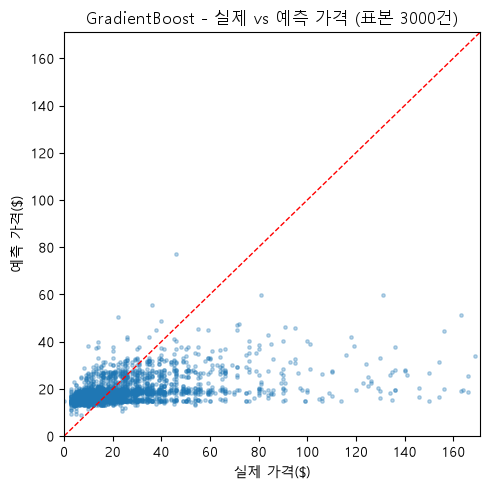

[종료] [1/5] GradientBoost 학습 | 2026-08-29 01:45:25 | 소요 16315.2초


In [5]:
with step('[1/5] GradientBoost 학습'):
    gbr = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=156)
    gbr.fit(X_train, y_train)
    preds_gbr = gbr.predict(X_test)
    rmsle_value = evaluate_org_price(y_test, preds_gbr)
    print(f'[GradientBoost] RMSLE: {rmsle_value:.4f}')
    plot_actual_vs_pred(y_test_price, np.expm1(preds_gbr), 'GradientBoost', plot_idx)


[시작] [2/5] LightGBM 학습 | 2026-08-29 01:45:25
[LightGBM] RMSLE: 0.6539


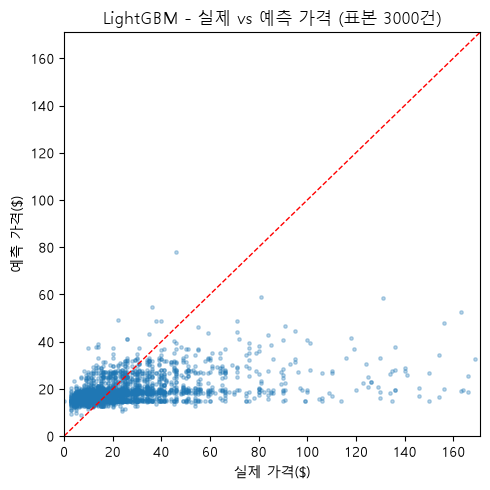

[종료] [2/5] LightGBM 학습 | 2026-08-29 01:57:56 | 소요 751.3초


In [6]:
with step('[2/5] LightGBM 학습'):
    lgbmr = LGBMRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05, random_state=156,
        num_leaves=8, verbose=-1,
    )
    lgbmr.fit(X_train, y_train)
    preds_lgbm = lgbmr.predict(X_test)
    rmsle_lgbm = evaluate_org_price(y_test, preds_lgbm)
    print(f'[LightGBM] RMSLE: {rmsle_lgbm:.4f}')
    plot_actual_vs_pred(y_test_price, np.expm1(preds_lgbm), 'LightGBM', plot_idx)


[시작] [3/5] XGBoost 학습 | 2026-08-29 01:57:56
[XGBoost] RMSLE: 0.6539


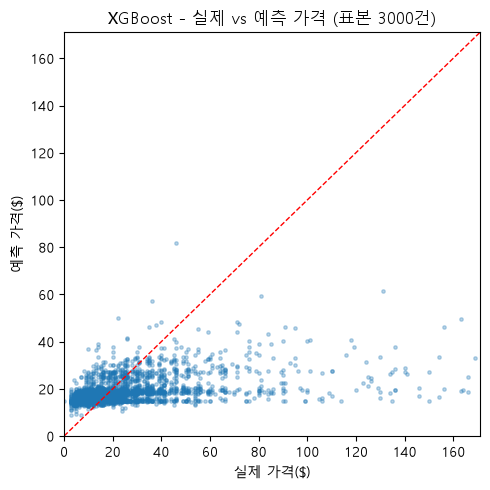

[종료] [3/5] XGBoost 학습 | 2026-08-29 02:00:55 | 소요 178.0초


In [7]:
with step('[3/5] XGBoost 학습'):
    xgbr = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05, random_state=156,
        tree_method='hist', n_jobs=-1,
    )
    xgbr.fit(X_train, y_train)
    preds_xgb = xgbr.predict(X_test)
    rmsle_xgb = evaluate_org_price(y_test, preds_xgb)
    print(f'[XGBoost] RMSLE: {rmsle_xgb:.4f}')
    plot_actual_vs_pred(y_test_price, np.expm1(preds_xgb), 'XGBoost', plot_idx)


[시작] [4/5] RandomForest 학습 | 2026-08-29 02:00:55
[RandomForest] RMSLE: 0.6442


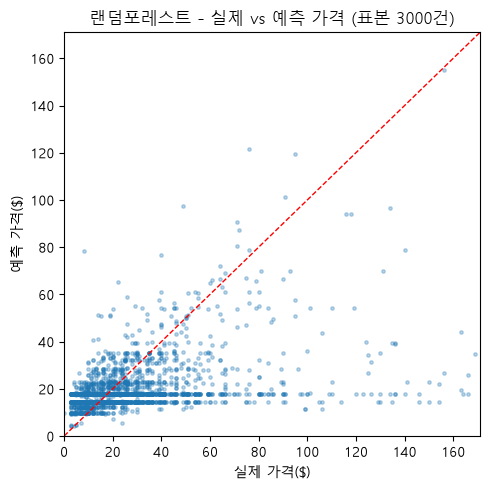

[종료] [4/5] RandomForest 학습 | 2026-08-29 03:41:02 | 소요 6007.1초


In [8]:
with step('[4/5] RandomForest 학습'):
    rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=156, n_jobs=-1)
    rfr.fit(X_train, y_train)
    preds_rf = rfr.predict(X_test)
    rmsle_rf = evaluate_org_price(y_test, preds_rf)
    print(f'[RandomForest] RMSLE: {rmsle_rf:.4f}')
    plot_actual_vs_pred(y_test_price, np.expm1(preds_rf), '랜덤포레스트', plot_idx)


[시작] [5/5] LogisticRegression(가격 구간분류) 학습 | 2026-08-29 03:41:02


c:\Users\jcs19\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LogisticRegression(구간분류)] RMSLE: 0.5679


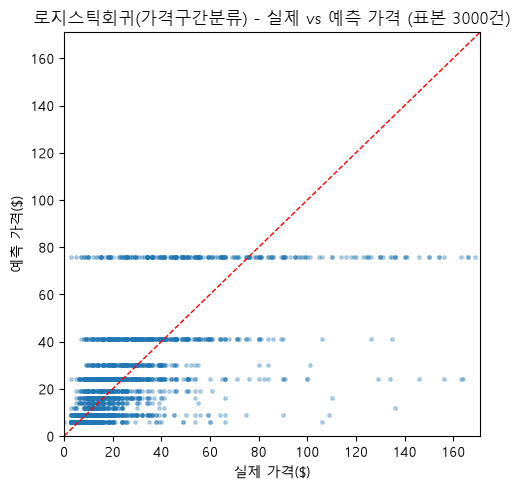

[종료] [5/5] LogisticRegression(가격 구간분류) 학습 | 2026-08-29 03:48:43 | 소요 461.6초


In [9]:
with step('[5/5] LogisticRegression(가격 구간분류) 학습'):
    n_bins = 10
    train_price = np.expm1(y_train)
    _, bin_edges = pd.qcut(train_price, q=n_bins, retbins=True, duplicates='drop')
    bin_labels = pd.cut(train_price, bins=bin_edges, include_lowest=True, labels=False)
    bin_representative = pd.Series(train_price).groupby(bin_labels).median()

    logreg_price = LogisticRegression(solver='lbfgs', max_iter=300, random_state=156)
    logreg_price.fit(X_train, bin_labels)
    pred_bin_test = logreg_price.predict(X_test)
    preds_price_logreg_binned = pd.Series(pred_bin_test).map(bin_representative).to_numpy()

    n_fallback = int(np.isnan(preds_price_logreg_binned).sum())
    if n_fallback:
        preds_price_logreg_binned = np.where(
            np.isnan(preds_price_logreg_binned), bin_representative.mean(), preds_price_logreg_binned
        )
        print(f'[경고] 구간 매핑 실패 대체값 사용: {n_fallback}건')

    rmsle_logreg_binned = rmsle(y_test_price, preds_price_logreg_binned)
    print(f'[LogisticRegression(구간분류)] RMSLE: {rmsle_logreg_binned:.4f}')
    plot_actual_vs_pred(y_test_price, preds_price_logreg_binned, '로지스틱회귀(가격구간분류)', plot_idx)


## 5. 정찬성 담당 5개 모델 RMSLE 종합

In [10]:
# 기술적 의미: 정찬성 담당 5개 모델의 RMSLE를 팀 취합 시트와 동일한 순서(GradientBoost/로지스틱회귀/LightGBM/XGBoost/랜덤포레스트)로 DataFrame에 담는다.
# 업무적 의미: 이 표 하나가 팀 취합 시트의 '정찬성' 행 5칸에 그대로 옮겨 적을 수 있는 최종 산출물이다.
with step('결과 종합'):
    jung_chansung_rmsle = pd.DataFrame([
        {'담당자': '정찬성', '모델': 'GradientBoost', 'RMSLE': rmsle_value, '비고': ''},
        {'담당자': '정찬성', '모델': '로지스틱 회귀', 'RMSLE': rmsle_logreg_binned, '비고': '가격 구간분류 우회 산출(§Part M) - 표준 방식 아님, 재확인 필요'},
        {'담당자': '정찬성', '모델': 'LightGBM', 'RMSLE': rmsle_lgbm, '비고': ''},
        {'담당자': '정찬성', '모델': 'XGBoost', 'RMSLE': rmsle_xgb, '비고': ''},
        {'담당자': '정찬성', '모델': '랜덤포레스트', 'RMSLE': rmsle_rf, '비고': ''},
    ])

    print('=== 정찬성 담당 5개 모델 RMSLE 종합 ===')
    print(jung_chansung_rmsle.to_string(index=False))


[시작] 결과 종합 | 2026-08-29 03:48:43
=== 정찬성 담당 5개 모델 RMSLE 종합 ===
담당자            모델    RMSLE                                        비고
정찬성 GradientBoost 0.653524                                          
정찬성       로지스틱 회귀 0.567947 가격 구간분류 우회 산출(§Part M) - 표준 방식 아님, 재확인 필요
정찬성      LightGBM 0.653883                                          
정찬성       XGBoost 0.653901                                          
정찬성        랜덤포레스트 0.644236                                          
[종료] 결과 종합 | 2026-08-29 03:48:43 | 소요 0.0초


In [11]:
pipeline_elapsed = time.time() - pipeline_start
print(f'=== 전체 실행 종료: {datetime.now().strftime(TIME_FMT)} | 총 소요시간 {pipeline_elapsed:.1f}초 ===')


=== 전체 실행 종료: 2026-08-29 03:48:43 | 총 소요시간 24052.0초 ===
